In [13]:
# ============================================================
# CELL 1 — Load Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

results      = pd.read_csv('../data/results.csv')
goalscorers  = pd.read_csv('../data/goalscorers.csv')
shootouts    = pd.read_csv('../data/shootouts.csv')
former_names = pd.read_csv('../data/former_names.csv')

results['date']     = pd.to_datetime(results['date'])
goalscorers['date'] = pd.to_datetime(goalscorers['date'])
shootouts['date']   = pd.to_datetime(shootouts['date'])

print('Loaded!')
print('results     :', results.shape)
print('goalscorers :', goalscorers.shape)
print('shootouts   :', shootouts.shape)
print('former_names:', former_names.shape)

Loaded!
results     : (49477, 9)
goalscorers : (47663, 8)
shootouts   : (678, 5)
former_names: (36, 4)


In [14]:
# ============================================================
# CELL 2 — Fix Country Names
# Some countries changed names (e.g. West Germany -> Germany)
# We must unify them before doing any calculation
# ============================================================
name_map = dict(zip(former_names['former'], former_names['current']))

def normalize(name):
    return name_map.get(name, name)

results['home_team']     = results['home_team'].apply(normalize)
results['away_team']     = results['away_team'].apply(normalize)

goalscorers['home_team'] = goalscorers['home_team'].apply(normalize)
goalscorers['away_team'] = goalscorers['away_team'].apply(normalize)
goalscorers['team']      = goalscorers['team'].apply(normalize)

shootouts['home_team']   = shootouts['home_team'].apply(normalize)
shootouts['away_team']   = shootouts['away_team'].apply(normalize)
shootouts['winner']      = shootouts['winner'].apply(normalize)

print('Country names normalized!')

Country names normalized!


In [15]:
# ============================================================
# CELL 3 — Drop rows with missing scores, create target label
# Label = who won the match
#   0 = home team won
#   1 = draw (tie)
#   2 = away team won
# ============================================================
results = results.dropna(subset=['home_score', 'away_score']).copy()

def get_outcome(row):
    if row['home_score'] > row['away_score']:
        return 0  # home win
    elif row['home_score'] == row['away_score']:
        return 1  # draw
    else:
        return 2  # away win

results['label'] = results.apply(get_outcome, axis=1)

print(results['label'].value_counts())
print('0 = home win, 1 = draw, 2 = away win')

label
0    24222
2    13962
1    11241
Name: count, dtype: int64
0 = home win, 1 = draw, 2 = away win


In [16]:
# ============================================================
# CELL 4 — Build team stats lookup table
# For each team, compute (using ALL past matches up to a date):
#   - win rate (how often they win)
#   - avg goals scored
#   - avg goals conceded
#   - shootout win rate
# We only use matches BEFORE the current match (no data leakage)
# ============================================================
results_sorted = results.sort_values('date').reset_index(drop=True)

def team_stats(team, before_date, n=20):
    past = results_sorted[
        (results_sorted['date'] < before_date) &
        ((results_sorted['home_team'] == team) | (results_sorted['away_team'] == team))
    ].tail(n)

    if len(past) == 0:
        return {'win_rate': 0.5, 'avg_scored': 1.0, 'avg_conceded': 1.0, 'n_matches': 0}

    wins, scored, conceded = [], [], []
    for _, m in past.iterrows():
        if m['home_team'] == team:
            wins.append(1 if m['home_score'] > m['away_score'] else 0)
            scored.append(m['home_score'])
            conceded.append(m['away_score'])
        else:
            wins.append(1 if m['away_score'] > m['home_score'] else 0)
            scored.append(m['away_score'])
            conceded.append(m['home_score'])

    return {
        'win_rate':     np.mean(wins),
        'avg_scored':   np.mean(scored),
        'avg_conceded': np.mean(conceded),
        'n_matches':    len(past)
    }

def shootout_win_rate(team, before_date):
    past = shootouts[
        (shootouts['date'] < before_date) &
        ((shootouts['home_team'] == team) | (shootouts['away_team'] == team))
    ]
    if len(past) == 0:
        return 0.5
    return (past['winner'] == team).sum() / len(past)

print('Functions defined!')

Functions defined!


In [17]:
# ============================================================
# CELL 5 — Build the feature table
# Each row = one match, with features computed from past data
# This cell takes 1-3 minutes to run — please wait
# ============================================================

# Use only matches from year 2000 onward to keep it fast
df = results_sorted[results_sorted['date'].dt.year >= 2000].copy()
df = df.reset_index(drop=True)

rows = []
for i, row in df.iterrows():
    if i % 500 == 0:
        print(f'Processing {i}/{len(df)}...')

    home = row['home_team']
    away = row['away_team']
    date = row['date']

    h = team_stats(home, date)
    a = team_stats(away, date)

    rows.append({
        # match info
        'date':              date,
        'home_team':         home,
        'away_team':         away,
        'is_neutral':        int(row['neutral']),
        'year':              date.year,
        'month':             date.month,
        # home team features
        'home_win_rate':     h['win_rate'],
        'home_avg_scored':   h['avg_scored'],
        'home_avg_conceded': h['avg_conceded'],
        'home_n_matches':    h['n_matches'],
        'home_shootout_wr':  shootout_win_rate(home, date),
        # away team features
        'away_win_rate':     a['win_rate'],
        'away_avg_scored':   a['avg_scored'],
        'away_avg_conceded': a['avg_conceded'],
        'away_n_matches':    a['n_matches'],
        'away_shootout_wr':  shootout_win_rate(away, date),
        # target
        'label':             row['label']
    })

feat = pd.DataFrame(rows)
print('Done! Shape:', feat.shape)
feat.head()

Processing 0/25363...
Processing 500/25363...
Processing 1000/25363...
Processing 1500/25363...
Processing 2000/25363...
Processing 2500/25363...
Processing 3000/25363...
Processing 3500/25363...
Processing 4000/25363...
Processing 4500/25363...
Processing 5000/25363...
Processing 5500/25363...
Processing 6000/25363...
Processing 6500/25363...
Processing 7000/25363...
Processing 7500/25363...
Processing 8000/25363...
Processing 8500/25363...
Processing 9000/25363...
Processing 9500/25363...
Processing 10000/25363...
Processing 10500/25363...
Processing 11000/25363...
Processing 11500/25363...
Processing 12000/25363...
Processing 12500/25363...
Processing 13000/25363...
Processing 13500/25363...
Processing 14000/25363...
Processing 14500/25363...
Processing 15000/25363...
Processing 15500/25363...
Processing 16000/25363...
Processing 16500/25363...
Processing 17000/25363...
Processing 17500/25363...
Processing 18000/25363...
Processing 18500/25363...
Processing 19000/25363...
Processing

,date,home_team,away_team,is_neutral,year,month,home_win_rate,home_avg_scored,home_avg_conceded,home_n_matches,home_shootout_wr,away_win_rate,away_avg_scored,away_avg_conceded,away_n_matches,away_shootout_wr,label
0,2000-01-04,Egypt,Togo,0,2000,1,0.20,1.15,1.50,20,0.538462,0.20,1.15,1.45,20,0.666667,0
1,2000-01-07,Tunisia,Togo,0,2000,1,0.45,1.40,0.90,20,0.600000,0.20,1.15,1.45,20,0.666667,0
2,2000-01-08,Trinidad and Tobago,Canada,0,2000,1,0.65,2.80,1.55,20,1.000000,0.35,0.80,1.10,20,0.500000,1
3,2000-01-09,Burkina Faso,Gabon,0,2000,1,0.30,1.50,1.60,20,0.600000,0.55,1.50,1.05,20,0.444444,1
4,2000-01-09,Guatemala,Armenia,1,2000,1,0.25,1.15,1.55,20,1.000000,0.25,0.80,1.45,20,0.500000,1


In [18]:
# ============================================================
# CELL 6 — Split into Train and Test sets
# Train on older matches, test on recent matches
# This is more realistic than random split for time-series data
# ============================================================
from sklearn.model_selection import train_test_split

FEATURES = [
    'is_neutral', 'year', 'month',
    'home_win_rate', 'home_avg_scored', 'home_avg_conceded', 'home_n_matches', 'home_shootout_wr',
    'away_win_rate', 'away_avg_scored', 'away_avg_conceded', 'away_n_matches', 'away_shootout_wr',
]

X = feat[FEATURES]
y = feat['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (20290, 13)
Test size : (5073, 13)


In [19]:
# ============================================================
# CELL 7 — Train the Model
# Random Forest: builds many decision trees and votes
# ============================================================
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print('Model trained!')

Model trained!


Accuracy: 54.15 %

              precision    recall  f1-score   support

    Home Win       0.57      0.82      0.67      2414
        Draw       0.33      0.07      0.12      1202
    Away Win       0.51      0.47      0.49      1457

    accuracy                           0.54      5073
   macro avg       0.47      0.45      0.43      5073
weighted avg       0.50      0.54      0.49      5073



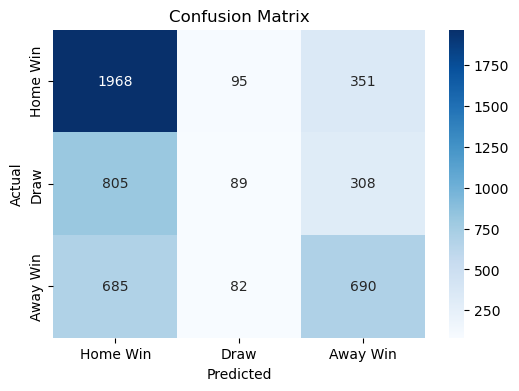

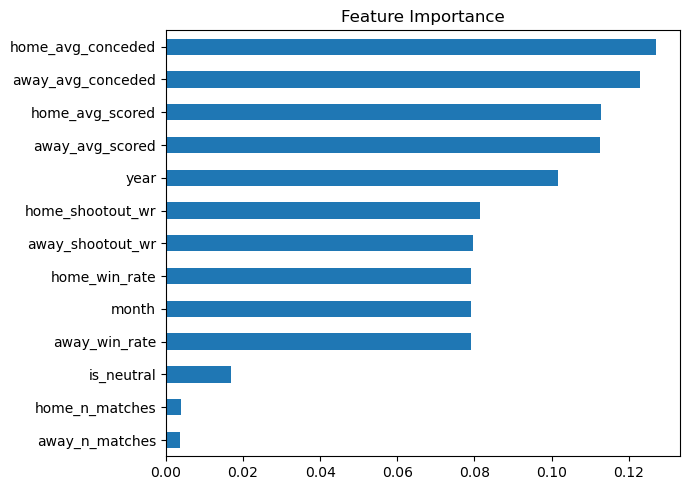

In [20]:
# ============================================================
# CELL 8 — Evaluate the Model
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 2), '%')
print()
print(classification_report(y_test, y_pred, target_names=['Home Win', 'Draw', 'Away Win']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Home Win', 'Draw', 'Away Win'],
            yticklabels=['Home Win', 'Draw', 'Away Win'],
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature importance
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', figsize=(7, 5), title='Feature Importance')
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# CELL 9 — Predict a Match Between Two Countries
# ============================================================
def predict_match(home_team, away_team, is_neutral=0):
    today = pd.Timestamp.today()

    h = team_stats(home_team, today)
    a = team_stats(away_team, today)

    input_row = pd.DataFrame([{
        'is_neutral':        is_neutral,
        'year':              today.year,
        'month':             today.month,
        'home_win_rate':     h['win_rate'],
        'home_avg_scored':   h['avg_scored'],
        'home_avg_conceded': h['avg_conceded'],
        'home_n_matches':    h['n_matches'],
        'home_shootout_wr':  shootout_win_rate(home_team, today),
        'away_win_rate':     a['win_rate'],
        'away_avg_scored':   a['avg_scored'],
        'away_avg_conceded': a['avg_conceded'],
        'away_n_matches':    a['n_matches'],
        'away_shootout_wr':  shootout_win_rate(away_team, today),
    }])

    pred  = model.predict(input_row)[0]
    proba = model.predict_proba(input_row)[0]
    label = {0: 'Home Win', 1: 'Draw', 2: 'Away Win'}

    print(f'\n  {home_team}  vs  {away_team}')
    print(f'  Venue     : {"Neutral" if is_neutral else home_team + " home ground"}')
    print(f'  Prediction: {label[pred]}')
    print(f'  {home_team} wins : {proba[0]*100:.1f}%')
    print(f'  Draw        : {proba[1]*100:.1f}%')
    print(f'  {away_team} wins : {proba[2]*100:.1f}%')

# ---- Try it here ----
predict_match('Brazil', 'Argentina')
predict_match('France', 'England')
predict_match('Spain', 'Germany', is_neutral=1)


  Brazil  vs  Argentina
  Venue     : Brazil home ground
  Prediction: Away Win
  Brazil wins : 36.5%
  Draw        : 19.5%
  Argentina wins : 44.0%

  France  vs  England
  Venue     : France home ground
  Prediction: Home Win
  France wins : 40.5%
  Draw        : 25.5%
  England wins : 34.0%

  Spain  vs  Germany
  Venue     : Neutral
  Prediction: Home Win
  Spain wins : 44.5%
  Draw        : 24.0%
  Germany wins : 31.5%
